In [32]:
from typing import TypedDict
from langgraph.graph import StateGraph,START,END
from langchain_ollama import ChatOllama


In [33]:
class SUBState(TypedDict):
    input_text:str
    translate:str

In [34]:
subgraph_llm=ChatOllama(model="llama3.1:8b")

In [51]:
def translate_text(state:SUBState):
    prompt = f"""
     Translate the following text to Spanish.
    Keep it natural and clear. Do not add extra content.
    Text:
    {state["input_text"]}
    """.strip()
    translated_text=subgraph_llm.invoke(prompt).content
    return{"translate":translate_text}

In [36]:
#building subgraph
subgraph=StateGraph(SUBState)
subgraph.add_node(translate_text,'translate_text')
subgraph.add_edge(START,"translate_text")
subgraph.add_edge("translate_text",END)
subgraph=subgraph.compile()


In [37]:
class ParentClass(TypedDict):
    question:str
    eng_ans:str
    translated_ans:str

In [38]:
parent_llm=ChatOllama(model="llama3.1:8b")

In [39]:
def translate_answer(state:ParentClass):
    result=subgraph.invoke({'input_text':state['eng_ans']})
    return {'translated_ans':result['translate']}

In [45]:
def generate_answer(state:ParentClass):
    
    answer = parent_llm.invoke(f"You are a helpful assistant. Answer clearly.\n\nQuestion: {state['question']}").content
    return {'eng_ans':answer}

In [47]:
parent_builder=StateGraph(ParentClass)
parent_builder.add_node(translate_answer,'translate_answer')
parent_builder.add_node(generate_answer,'generate_answer')
parent_builder.add_edge(START,'generate_answer')
parent_builder.add_edge('generate_answer','translate_answer')
parent_builder.add_edge('translate_answer',END)

In [48]:
parent_graph=parent_builder.compile()

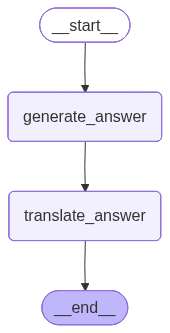

In [49]:
parent_graph


In [53]:
parent_graph.invoke({'question':"does ollama have the capabilty to tranlate into different languages"})

{'question': 'does ollama have the capabilty to tranlate into different languages',
 'eng_ans': 'Yes, OllyDbg is a powerful debugging tool for Windows, but it\'s not capable of translating text into different languages on its own.\n\nHowever, if you\'re referring to "OllyRich" or another similar tool that integrates translation capabilities with code debugging, then yes, those tools do have the ability to translate text and code in real-time into multiple languages.',
 'translated_ans': <function __main__.translate_text(state: __main__.SUBState)>}